In [52]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, SplineTransformer, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5
N_LATENT_SCORES = 20

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
NONLINEAR_FIGURES_DIR = FIGURES_DIR / "nonlinear_benchmark"
MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NONLINEAR_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^A-Za-z0-9_\-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text[:100] if text else "unknown"


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def q2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    if denom <= 0:
        return np.nan
    return float(1 - np.sum((y_true - y_pred) ** 2) / denom)


def find_file(candidates, search_dirs):
    for d in search_dirs:
        for name in candidates:
            p = d / name
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not find any of {candidates} in {[str(d) for d in search_dirs]}")

SEARCH_DIRS = [DATA_RAW]

# 1. Load Raw Data and Previous Outputs

In [53]:
FILES = {
    "descriptor": find_file(["Molecular_Descriptor.xlsx", "molecular_descriptor.xlsx"], SEARCH_DIRS),
    "activity": find_file(["ERα_activity.xlsx", "ERa_activity.xlsx", "ER_activity.xlsx"], SEARCH_DIRS),
    "admet": find_file(["ADMET.xlsx", "admet.xlsx"], SEARCH_DIRS),
}

desc_train = pd.read_excel(FILES["descriptor"], sheet_name="training")
desc_test = pd.read_excel(FILES["descriptor"], sheet_name="test")

activity_train = pd.read_excel(FILES["activity"], sheet_name="training")
admet_train = pd.read_excel(FILES["admet"], sheet_name="training")

smiles_col = desc_train.columns[0]
activity_smiles_col = activity_train.columns[0]
admet_smiles_col = admet_train.columns[0]

X_all = desc_train.drop(columns=["SMILES"]).apply(pd.to_numeric, errors="coerce")
y = activity_train["pIC50"].astype(float).reset_index(drop=True)

preprocessing_candidates = pd.read_csv(RESULTS_DIR / "descriptor_preprocessing_candidates.csv")
for col in ["is_constant", "is_near_constant", "is_binary_like", "is_rare_binary_like"]:
    if col in preprocessing_candidates.columns:
        preprocessing_candidates[col] = preprocessing_candidates[col].fillna(False).astype(bool)

preprocessing_candidates["candidate_super_block"] = preprocessing_candidates["candidate_super_block"].fillna("not_assigned")

# Baseline predictions
pls_cv_path = RESULTS_DIR / "pls_cv_predictions_primary_selected_model.csv"
pls_cv_predictions = pd.read_csv(pls_cv_path)
pls_cv_predictions["SMILES"] = pls_cv_predictions["SMILES"].astype(str)

print("X_all shape:", X_all.shape)
print("y length:", len(y))
display(preprocessing_candidates.head())
display(pls_cv_predictions.head())

X_all shape: (1974, 729)
y length: 1974


,descriptor,variance,std,range,n_unique_values,unique_value_ratio,dominant_value,dominant_value_ratio,is_constant,dominant_value_ge_90pct,...,is_integer_like,is_binary_like,is_low_cardinality,is_continuous_like,is_rare_binary_like,descriptor_category,candidate_super_block,remove_before_pca_pls,review_before_pca_pls,recommended_action
0,nB,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom count,block_Y_topological_connectivity_structure,True,False,remove_constant_descriptor
1,nBondsQ,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Bond count,block_Y_topological_connectivity_structure,True,False,remove_constant_descriptor
2,nHsNH3p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
3,nHssNH2p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
4,nHsssNHp,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,...,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor


,SMILES,dataset_name,n_components,y_true,y_pred_cv,residual_cv,pIC50,observed_pIC50,predicted_pIC50_cv,abs_residual_cv
0,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCC3)c4ccc(OCCN5C...,primary_remove_constant_only,20,8.602060,8.396612,0.205448,8.602060,8.602060,8.396612,0.205448
1,Oc1ccc2O[C@H]([C@H](Sc2c1)C3CCCCCC3)c4ccc(OCCN...,primary_remove_constant_only,20,8.124939,8.359938,-0.234999,8.124939,8.124939,8.359938,0.234999
2,Oc1ccc(cc1)[C@H]2Sc3cc(O)ccc3O[C@H]2c4ccc(OCCN...,primary_remove_constant_only,20,8.508638,8.395721,0.112918,8.508638,8.508638,8.395721,0.112918
3,Oc1ccc2O[C@H]([C@@H](CC3CCCCC3)Sc2c1)c4ccc(OCC...,primary_remove_constant_only,20,8.408935,8.042350,0.366586,8.408935,8.408935,8.042350,0.366586
4,Oc1ccc2O[C@H]([C@@H](Cc3ccccc3)Sc2c1)c4ccc(OCC...,primary_remove_constant_only,20,8.130768,8.219313,-0.088545,8.130768,8.130768,8.219313,0.088545


# 2. Define Descriptor Sets

The primary descriptor set follows the main PLS analysis: remove only constant descriptors. Near-constant and rare binary descriptors are retained in the main descriptor set.

In [54]:
constant_descriptors = preprocessing_candidates.loc[
    preprocessing_candidates.get("is_constant", False), "descriptor"
].tolist()

primary_descriptors = [d for d in X_all.columns if d not in set(constant_descriptors)]
X_primary = X_all[primary_descriptors].copy()

if X_primary.isna().sum().sum() > 0:
    X_primary = X_primary.fillna(X_primary.median())

# Candidate super-block descriptor sets
BLOCK_X_LABEL = "block_X_local_electronic_atom_environment"
BLOCK_Y_LABEL = "block_Y_topological_connectivity_structure"

block_x_descriptors = preprocessing_candidates.loc[
    (preprocessing_candidates["candidate_super_block"] == BLOCK_X_LABEL)
    & (~preprocessing_candidates.get("is_constant", False)),
    "descriptor",
].tolist()
block_y_descriptors = preprocessing_candidates.loc[
    (preprocessing_candidates["candidate_super_block"] == BLOCK_Y_LABEL)
    & (~preprocessing_candidates.get("is_constant", False)),
    "descriptor",
].tolist()
not_assigned_descriptors = preprocessing_candidates.loc[
    (preprocessing_candidates["candidate_super_block"] == "not_assigned")
    & (~preprocessing_candidates.get("is_constant", False)),
    "descriptor",
].tolist()

block_x_descriptors = [d for d in block_x_descriptors if d in X_primary.columns]
block_y_descriptors = [d for d in block_y_descriptors if d in X_primary.columns]
not_assigned_descriptors = [d for d in not_assigned_descriptors if d in X_primary.columns]

X_block_x = X_primary[block_x_descriptors].copy()
X_block_y = X_primary[block_y_descriptors].copy()
X_block_xy = X_primary[block_x_descriptors + block_y_descriptors].copy()
X_not_assigned = X_primary[not_assigned_descriptors].copy()

print("Primary descriptors:", X_primary.shape[1])
print("Block X descriptors:", X_block_x.shape[1])
print("Block Y descriptors:", X_block_y.shape[1])
print("Block X + Y descriptors:", X_block_xy.shape[1])
print("Not assigned descriptors:", X_not_assigned.shape[1])

Primary descriptors: 504
Block X descriptors: 335
Block Y descriptors: 129
Block X + Y descriptors: 464
Not assigned descriptors: 40


# 3. Common Cross-Validation Folds

In [55]:
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(X_primary, y))

# Save fold assignment for reproducibility
fold_assignment = pd.DataFrame({"SMILES": desc_train["SMILES"].astype(str).values})
fold_assignment["fold"] = -1
for fold_id, (_, val_idx) in enumerate(cv_splits, start=1):
    fold_assignment.loc[val_idx, "fold"] = fold_id
fold_assignment.to_csv(RESULTS_DIR / "nonlinear_common_cv_fold_assignment.csv", index=False)

display(fold_assignment["fold"].value_counts().sort_index().reset_index(name="n_compounds"))

,fold,n_compounds
0,1,395
1,2,395
2,3,395
3,4,395
4,5,394


# 4. Model-Evaluation Helpers

The evaluation is intentionally compact. The nonlinear models are benchmarks rather than final explanatory models.

In [56]:
def evaluate_model_cv(model, X_df, y, model_name, feature_set_name, cv_splits):
    """Evaluate one estimator using fixed CV splits."""
    X_df = X_df.copy().reset_index(drop=True)
    y = pd.Series(y).astype(float).reset_index(drop=True)

    y_pred = np.empty(len(y), dtype=float)
    fold_records = []

    for fold_id, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        estimator = clone(model)
        estimator.fit(X_df.iloc[train_idx], y.iloc[train_idx])
        pred = estimator.predict(X_df.iloc[val_idx])
        pred = np.asarray(pred).ravel()
        y_pred[val_idx] = pred

        fold_records.append({
            "model_name": model_name,
            "feature_set_name": feature_set_name,
            "fold": fold_id,
            "rmse": rmse(y.iloc[val_idx], pred),
            "mae": float(mean_absolute_error(y.iloc[val_idx], pred)),
            "r2": float(r2_score(y.iloc[val_idx], pred)),
        })

    pred_df = pd.DataFrame({
        "SMILES": desc_train["SMILES"].astype(str).values,
        "model_name": model_name,
        "feature_set_name": feature_set_name,
        "observed_pIC50": y.values,
        "predicted_pIC50_cv": y_pred,
        "residual_cv": y.values - y_pred,
    })
    pred_df["abs_residual_cv"] = pred_df["residual_cv"].abs()

    fold_df = pd.DataFrame(fold_records)
    summary = {
        "model_name": model_name,
        "feature_set_name": feature_set_name,
        "n_features": int(X_df.shape[1]),
        "n_latent_components": np.nan,
        "feature_representation": "raw_or_engineered_features",
        "rmse_cv_global": rmse(y, y_pred),
        "mae_cv_global": float(mean_absolute_error(y, y_pred)),
        "q2_cv_global": q2_score(y, y_pred),
        "r2_cv_global": float(r2_score(y, y_pred)),
        "fold_rmse_mean": float(fold_df["rmse"].mean()),
        "fold_rmse_sd": float(fold_df["rmse"].std(ddof=1)),
        "fold_mae_mean": float(fold_df["mae"].mean()),
        "fold_r2_mean": float(fold_df["r2"].mean()),
    }
    return summary, fold_df, pred_df


def evaluate_pls_score_model_cv(
    model,
    X_df,
    y,
    n_components,
    model_name,
    feature_set_name,
    cv_splits,
):
    """Evaluate a nonlinear model on fold-wise PLS score features.

    In each outer CV fold:
    1. Fit scaler + PLS on the training fold only.
    2. Transform both training and validation descriptors into PLS scores.
    3. Fit the nonlinear model on training PLS scores.
    4. Predict validation pIC50.
    """
    X_df = X_df.copy().reset_index(drop=True)
    y = pd.Series(y).astype(float).reset_index(drop=True)

    n_components = int(min(n_components, X_df.shape[1], X_df.shape[0] - 1))

    y_pred = np.empty(len(y), dtype=float)
    fold_records = []

    score_cols = [f"PLS_score_{i+1}" for i in range(n_components)]

    for fold_id, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        X_train = X_df.iloc[train_idx]
        X_val = X_df.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        pls = PLSRegression(n_components=n_components)
        pls.fit(X_train_scaled, y_train)

        X_train_scores = pd.DataFrame(
            pls.transform(X_train_scaled),
            columns=score_cols,
            index=X_train.index,
        )

        X_val_scores = pd.DataFrame(
            pls.transform(X_val_scaled),
            columns=score_cols,
            index=X_val.index,
        )

        estimator = clone(model)
        estimator.fit(X_train_scores, y_train)

        pred = np.asarray(estimator.predict(X_val_scores)).ravel()
        y_pred[val_idx] = pred

        fold_records.append({
            "model_name": model_name,
            "feature_set_name": feature_set_name,
            "fold": fold_id,
            "rmse": rmse(y_val, pred),
            "mae": float(mean_absolute_error(y_val, pred)),
            "r2": float(r2_score(y_val, pred)),
        })

    pred_df = pd.DataFrame({
        "SMILES": desc_train["SMILES"].astype(str).values,
        "model_name": model_name,
        "feature_set_name": feature_set_name,
        "observed_pIC50": y.values,
        "predicted_pIC50_cv": y_pred,
        "residual_cv": y.values - y_pred,
    })
    pred_df["abs_residual_cv"] = pred_df["residual_cv"].abs()

    fold_df = pd.DataFrame(fold_records)

    summary = {
        "model_name": model_name,
        "feature_set_name": feature_set_name,
        "n_features": int(n_components),
        "n_input_features": int(n_components),
        "n_source_descriptors": int(X_df.shape[1]),
        "n_latent_components": int(n_components),
        "n_latent_scores_used": int(n_components),
        "feature_representation": "foldwise_PLS_score_features",
        "rmse_cv_global": rmse(y, y_pred),
        "mae_cv_global": float(mean_absolute_error(y, y_pred)),
        "q2_cv_global": q2_score(y, y_pred),
        "r2_cv_global": float(r2_score(y, y_pred)),
        "fold_rmse_mean": float(fold_df["rmse"].mean()),
        "fold_rmse_sd": float(fold_df["rmse"].std(ddof=1)),
        "fold_mae_mean": float(fold_df["mae"].mean()),
        "fold_r2_mean": float(fold_df["r2"].mean()),
    }

    return summary, fold_df, pred_df


def evaluate_pca_score_model_cv(
    model,
    X_df,
    y,
    n_components,
    model_name,
    feature_set_name,
    cv_splits,
):
    """Evaluate a model on fold-wise PCA score features.

    In each outer CV fold:
    1. Fit scaler + PCA on the training fold only.
    2. Transform both training and validation descriptors into PCA scores.
    3. Fit the nonlinear model on training PCA scores.
    4. Predict validation pIC50.
    """
    X_df = X_df.copy().reset_index(drop=True)
    y = pd.Series(y).astype(float).reset_index(drop=True)

    n_components = int(min(n_components, X_df.shape[1], X_df.shape[0] - 1))
    score_cols = [f"PCA_score_{i+1}" for i in range(n_components)]

    y_pred = np.empty(len(y), dtype=float)
    fold_records = []

    for fold_id, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        X_train = X_df.iloc[train_idx]
        X_val = X_df.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        pca = PCA(n_components=n_components, svd_solver="full")
        X_train_scores = pd.DataFrame(
            pca.fit_transform(X_train_scaled),
            columns=score_cols,
            index=X_train.index,
        )

        X_val_scores = pd.DataFrame(
            pca.transform(X_val_scaled),
            columns=score_cols,
            index=X_val.index,
        )

        estimator = clone(model)
        estimator.fit(X_train_scores, y_train)

        pred = np.asarray(estimator.predict(X_val_scores)).ravel()
        y_pred[val_idx] = pred

        fold_records.append({
            "model_name": model_name,
            "feature_set_name": feature_set_name,
            "fold": fold_id,
            "rmse": rmse(y_val, pred),
            "mae": float(mean_absolute_error(y_val, pred)),
            "r2": float(r2_score(y_val, pred)),
        })

    pred_df = pd.DataFrame({
        "SMILES": desc_train["SMILES"].astype(str).values,
        "model_name": model_name,
        "feature_set_name": feature_set_name,
        "observed_pIC50": y.values,
        "predicted_pIC50_cv": y_pred,
        "residual_cv": y.values - y_pred,
    })
    pred_df["abs_residual_cv"] = pred_df["residual_cv"].abs()

    fold_df = pd.DataFrame(fold_records)

    summary = {
        "model_name": model_name,
        "feature_set_name": feature_set_name,
        "n_features": int(n_components),
        "n_input_features": int(n_components),
        "n_source_descriptors": int(X_df.shape[1]),
        "n_latent_components": int(n_components),
        "n_latent_scores_used": int(n_components),
        "feature_representation": "foldwise_PCA_score_features",
        "rmse_cv_global": rmse(y, y_pred),
        "mae_cv_global": float(mean_absolute_error(y, y_pred)),
        "q2_cv_global": q2_score(y, y_pred),
        "r2_cv_global": float(r2_score(y, y_pred)),
        "fold_rmse_mean": float(fold_df["rmse"].mean()),
        "fold_rmse_sd": float(fold_df["rmse"].std(ddof=1)),
        "fold_mae_mean": float(fold_df["mae"].mean()),
        "fold_r2_mean": float(fold_df["r2"].mean()),
    }

    return summary, fold_df, pred_df

# 5. Add Linear PLS Baseline

In [57]:
model_summaries = []
fold_metrics_all = []
predictions_all = []

selected_pls_components_from_03 = 20

baseline_pred = pls_cv_predictions[["SMILES", "observed_pIC50", "predicted_pIC50_cv", "residual_cv", "abs_residual_cv"]].copy()
baseline_pred["model_name"] = "linear_PLS_from_03"
baseline_pred["feature_set_name"] = "primary_full_constant_removed"

baseline_fold_records = []

for fold_id, (_, val_idx) in enumerate(cv_splits, start=1):
    y_val = baseline_pred["observed_pIC50"].iloc[val_idx]
    pred_val = baseline_pred["predicted_pIC50_cv"].iloc[val_idx]

    baseline_fold_records.append({
        "model_name": "linear_PLS_from_03",
        "feature_set_name": "primary_full_constant_removed",
        "fold": fold_id,
        "rmse": rmse(y_val, pred_val),
        "mae": float(mean_absolute_error(y_val, pred_val)),
        "r2": float(r2_score(y_val, pred_val)),
    })

baseline_fold_df = pd.DataFrame(baseline_fold_records)

baseline_summary = {
    "model_name": "linear_PLS_from_03",
    "feature_set_name": "primary_full_constant_removed",
    "n_features": int(X_primary.shape[1]),
    "n_input_features": int(X_primary.shape[1]),
    "n_source_descriptors": int(X_primary.shape[1]),
    "n_latent_components": int(selected_pls_components_from_03),
    "n_latent_scores_used": int(selected_pls_components_from_03),
    "feature_representation": "raw_descriptors_to_linear_PLS_components",
    "rmse_cv_global": rmse(
        baseline_pred["observed_pIC50"],
        baseline_pred["predicted_pIC50_cv"]
    ),
    "mae_cv_global": float(mean_absolute_error(
        baseline_pred["observed_pIC50"],
        baseline_pred["predicted_pIC50_cv"]
    )),
    "q2_cv_global": q2_score(
        baseline_pred["observed_pIC50"],
        baseline_pred["predicted_pIC50_cv"]
    ),
    "r2_cv_global": float(r2_score(
        baseline_pred["observed_pIC50"],
        baseline_pred["predicted_pIC50_cv"]
    )),
    "fold_rmse_mean": float(baseline_fold_df["rmse"].mean()),
    "fold_rmse_sd": float(baseline_fold_df["rmse"].std(ddof=1)),
    "fold_mae_mean": float(baseline_fold_df["mae"].mean()),
    "fold_r2_mean": float(baseline_fold_df["r2"].mean()),
}
model_summaries.append(baseline_summary)
predictions_all.append(baseline_pred)
fold_metrics_all.append(baseline_fold_df)

pd.DataFrame(model_summaries)

,model_name,feature_set_name,n_features,n_input_features,n_source_descriptors,n_latent_components,n_latent_scores_used,feature_representation,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_mae_mean,fold_r2_mean
0,linear_PLS_from_03,primary_full_constant_removed,504,504,504,20,20,raw_descriptors_to_linear_PLS_components,0.855541,0.641078,0.638359,0.638359,0.854507,0.046696,0.641076,0.637908


# 6. Latent-Score Nonlinear Benchmarks

In [58]:
inner_cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

tuned_spline_ridge = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("spline", SplineTransformer(degree=3, include_bias=False)),
        ("ridge", Ridge()),
    ]),
    param_grid={
        "spline__n_knots": [4, 5, 6],
        "ridge__alpha": [0.1, 1.0, 10.0, 100.0],
    },
    scoring="neg_root_mean_squared_error",
    cv=inner_cv,
    n_jobs=-1,
)

# PLS-score nonlinear models
# These models use the same latent representation size as the linear PLS baseline

pls_score_models = [
    (
        "ridge_on_PLS_scores",
        Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=10.0)),
        ]),
        N_LATENT_SCORES,
        "PLS_scores_foldwise",
    ),
    (
        "tuned_spline_ridge_on_PLS_scores",
        tuned_spline_ridge,
        min(8, N_LATENT_SCORES),
        "PLS_scores_foldwise_top8_spline_tuned",
    ),
    (
        "rbf_svr_on_PLS_scores",
        Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")),
        ]),
        N_LATENT_SCORES,
        "PLS_scores_foldwise",
    ),
    (
        "kernel_ridge_rbf_on_PLS_scores",
        Pipeline([
            ("scaler", StandardScaler()),
            ("krr", KernelRidge(kernel="rbf", alpha=1.0, gamma=None)),
        ]),
        N_LATENT_SCORES,
        "PLS_scores_foldwise",
    ),
    (
        "random_forest_on_PLS_scores",
        RandomForestRegressor(
            n_estimators=300,
            max_features="sqrt",
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        N_LATENT_SCORES,
        "PLS_scores_foldwise",
    ),
    (
        "hist_gradient_boosting_on_PLS_scores",
        HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=RANDOM_STATE,
        ),
        N_LATENT_SCORES,
        "PLS_scores_foldwise",
    ),
    (
        "quadratic_ridge_on_PLS_scores",
        Pipeline([
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("ridge", Ridge(alpha=10.0)),
        ]),
        min(8, N_LATENT_SCORES),
        "PLS_scores_foldwise_top8_quadratic",
    ),
]

for model_name, model, n_scores, feature_set_name in pls_score_models:
    print("Evaluating", model_name, "on", feature_set_name)

    summary, folds, pred = evaluate_pls_score_model_cv(
        model=model,
        X_df=X_primary,
        y=y,
        n_components=n_scores,
        model_name=model_name,
        feature_set_name=feature_set_name,
        cv_splits=cv_splits,
    )

    model_summaries.append(summary)
    fold_metrics_all.append(folds)
    predictions_all.append(pred)


# PCA-score nonlinear models
# PCA is unsupervised. These models ask whether nonlinear modelling on unsupervised latent descriptor structure improves the residual pattern.

pca_score_models = [
    (
        "ridge_on_PCA_scores",
        Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=10.0)),
        ]),
        N_LATENT_SCORES,
        "PCA_scores_foldwise",
    ),
    (
        "spline_ridge_on_PCA_scores",
        Pipeline([
            ("scaler", StandardScaler()),
            ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
            ("ridge", Ridge(alpha=10.0)),
        ]),
        min(8, N_LATENT_SCORES),
        "PCA_scores_foldwise_top8_spline",
    ),
    (
        "random_forest_on_PCA_scores",
        RandomForestRegressor(
            n_estimators=300,
            max_features="sqrt",
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        N_LATENT_SCORES,
        "PCA_scores_foldwise",
    ),
    (
        "hist_gradient_boosting_on_PCA_scores",
        HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=RANDOM_STATE,
        ),
        N_LATENT_SCORES,
        "PCA_scores_foldwise",
    ),
]

for model_name, model, n_scores, feature_set_name in pca_score_models:
    print("Evaluating", model_name, "on", feature_set_name)

    summary, folds, pred = evaluate_pca_score_model_cv(
        model=model,
        X_df=X_primary,
        y=y,
        n_components=n_scores,
        model_name=model_name,
        feature_set_name=feature_set_name,
        cv_splits=cv_splits,
    )

    model_summaries.append(summary)
    fold_metrics_all.append(folds)
    predictions_all.append(pred)


pd.DataFrame(model_summaries).sort_values("q2_cv_global", ascending=False)

Evaluating ridge_on_PLS_scores on PLS_scores_foldwise
Evaluating tuned_spline_ridge_on_PLS_scores on PLS_scores_foldwise_top8_spline_tuned
Evaluating rbf_svr_on_PLS_scores on PLS_scores_foldwise
Evaluating kernel_ridge_rbf_on_PLS_scores on PLS_scores_foldwise
Evaluating random_forest_on_PLS_scores on PLS_scores_foldwise
Evaluating hist_gradient_boosting_on_PLS_scores on PLS_scores_foldwise
Evaluating quadratic_ridge_on_PLS_scores on PLS_scores_foldwise_top8_quadratic
Evaluating ridge_on_PCA_scores on PCA_scores_foldwise
Evaluating spline_ridge_on_PCA_scores on PCA_scores_foldwise_top8_spline
Evaluating random_forest_on_PCA_scores on PCA_scores_foldwise
Evaluating hist_gradient_boosting_on_PCA_scores on PCA_scores_foldwise


,model_name,feature_set_name,n_features,n_input_features,n_source_descriptors,n_latent_components,n_latent_scores_used,feature_representation,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_mae_mean,fold_r2_mean
6,hist_gradient_boosting_on_PLS_scores,PLS_scores_foldwise,20,20,504,20,20,foldwise_PLS_score_features,0.752146,0.554735,0.720488,0.720488,0.751574,0.032662,0.554733,0.719619
3,rbf_svr_on_PLS_scores,PLS_scores_foldwise,20,20,504,20,20,foldwise_PLS_score_features,0.761128,0.558930,0.713772,0.713772,0.759982,0.046779,0.558931,0.712907
5,random_forest_on_PLS_scores,PLS_scores_foldwise,20,20,504,20,20,foldwise_PLS_score_features,0.761345,0.584724,0.713609,0.713609,0.760971,0.026664,0.584727,0.713004
11,hist_gradient_boosting_on_PCA_scores,PCA_scores_foldwise,20,20,504,20,20,foldwise_PCA_score_features,0.775600,0.581776,0.702784,0.702784,0.774844,0.038481,0.581782,0.702148
10,random_forest_on_PCA_scores,PCA_scores_foldwise,20,20,504,20,20,foldwise_PCA_score_features,0.793931,0.611698,0.688569,0.688569,0.793306,0.035564,0.611706,0.688006
1,ridge_on_PLS_scores,PLS_scores_foldwise,20,20,504,20,20,foldwise_PLS_score_features,0.854648,0.640909,0.639114,0.639114,0.853635,0.046162,0.640906,0.638665
0,linear_PLS_from_03,primary_full_constant_removed,504,504,504,20,20,raw_descriptors_to_linear_PLS_components,0.855541,0.641078,0.638359,0.638359,0.854507,0.046696,0.641076,0.637908
2,tuned_spline_ridge_on_PLS_scores,PLS_scores_foldwise_top8_spline_tuned,8,8,504,8,8,foldwise_PLS_score_features,0.856727,0.662488,0.637356,0.637356,0.856006,0.039226,0.662490,0.636421
7,quadratic_ridge_on_PLS_scores,PLS_scores_foldwise_top8_quadratic,8,8,504,8,8,foldwise_PLS_score_features,0.974754,0.657569,0.530553,0.530553,0.952748,0.229894,0.657558,0.531655
8,ridge_on_PCA_scores,PCA_scores_foldwise,20,20,504,20,20,foldwise_PCA_score_features,0.992875,0.778798,0.512937,0.512937,0.992062,0.045133,0.778808,0.512181


# 7. Nonparametric Reference Models on Original Descriptors

These models test whether nonlinear models can improve prediction in the original descriptor space.

In [59]:
original_descriptor_models = [
    (
        "random_forest_primary_descriptors",
        RandomForestRegressor(
            n_estimators=300,
            max_features="sqrt",
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_primary,
        "primary_full_constant_removed",
    ),
    (
        "hist_gradient_boosting_primary_descriptors",
        HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=RANDOM_STATE,
        ),
        X_primary,
        "primary_full_constant_removed",
    ),
    (
        "random_forest_block_X_plus_Y",
        RandomForestRegressor(
            n_estimators=300,
            max_features="sqrt",
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_block_xy,
        "block_X_plus_block_Y",
    ),
    (
        "hist_gradient_boosting_block_X_plus_Y",
        HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=RANDOM_STATE,
        ),
        X_block_xy,
        "block_X_plus_block_Y",
    ),
]

for model_name, model, X_feat, feature_set_name in original_descriptor_models:
    print("Evaluating", model_name, "on", feature_set_name)
    summary, folds, pred = evaluate_model_cv(model, X_feat, y, model_name, feature_set_name, cv_splits)
    summary["n_input_features"] = int(X_feat.shape[1])
    summary["n_source_descriptors"] = int(X_feat.shape[1])
    summary["n_latent_components"] = np.nan
    summary["n_latent_scores_used"] = np.nan
    summary["feature_representation"] = "raw_descriptor_features"
    model_summaries.append(summary)
    fold_metrics_all.append(folds)
    predictions_all.append(pred)

model_comparison = pd.DataFrame(model_summaries).sort_values("q2_cv_global", ascending=False)
model_comparison.to_csv(RESULTS_DIR / "nonlinear_model_comparison_summary.csv", index=False)

display(model_comparison)

Evaluating random_forest_primary_descriptors on primary_full_constant_removed
Evaluating hist_gradient_boosting_primary_descriptors on primary_full_constant_removed
Evaluating random_forest_block_X_plus_Y on block_X_plus_block_Y
Evaluating hist_gradient_boosting_block_X_plus_Y on block_X_plus_block_Y


,model_name,feature_set_name,n_features,n_input_features,n_source_descriptors,n_latent_components,n_latent_scores_used,feature_representation,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_mae_mean,fold_r2_mean
13,hist_gradient_boosting_primary_descriptors,primary_full_constant_removed,504,504,504,NaN,NaN,raw_descriptor_features,0.688648,0.496382,0.765690,0.765690,0.687668,0.041160,0.496386,0.765305
15,hist_gradient_boosting_block_X_plus_Y,block_X_plus_block_Y,464,464,464,NaN,NaN,raw_descriptor_features,0.692975,0.499084,0.762736,0.762736,0.692147,0.037942,0.499085,0.762315
14,random_forest_block_X_plus_Y,block_X_plus_block_Y,464,464,464,NaN,NaN,raw_descriptor_features,0.707118,0.529729,0.752953,0.752953,0.706603,0.030513,0.529741,0.752460
12,random_forest_primary_descriptors,primary_full_constant_removed,504,504,504,NaN,NaN,raw_descriptor_features,0.708085,0.530645,0.752277,0.752277,0.707359,0.036218,0.530658,0.751810
6,hist_gradient_boosting_on_PLS_scores,PLS_scores_foldwise,20,20,504,20.0,20.0,foldwise_PLS_score_features,0.752146,0.554735,0.720488,0.720488,0.751574,0.032662,0.554733,0.719619
3,rbf_svr_on_PLS_scores,PLS_scores_foldwise,20,20,504,20.0,20.0,foldwise_PLS_score_features,0.761128,0.558930,0.713772,0.713772,0.759982,0.046779,0.558931,0.712907
5,random_forest_on_PLS_scores,PLS_scores_foldwise,20,20,504,20.0,20.0,foldwise_PLS_score_features,0.761345,0.584724,0.713609,0.713609,0.760971,0.026664,0.584727,0.713004
11,hist_gradient_boosting_on_PCA_scores,PCA_scores_foldwise,20,20,504,20.0,20.0,foldwise_PCA_score_features,0.775600,0.581776,0.702784,0.702784,0.774844,0.038481,0.581782,0.702148
10,random_forest_on_PCA_scores,PCA_scores_foldwise,20,20,504,20.0,20.0,foldwise_PCA_score_features,0.793931,0.611698,0.688569,0.688569,0.793306,0.035564,0.611706,0.688006
1,ridge_on_PLS_scores,PLS_scores_foldwise,20,20,504,20.0,20.0,foldwise_PLS_score_features,0.854648,0.640909,0.639114,0.639114,0.853635,0.046162,0.640906,0.638665


In [60]:
def assign_model_family(model_name, feature_representation):
    if model_name == "linear_PLS_from_03":
        return "linear_PLS_baseline"

    if feature_representation == "foldwise_PLS_score_features":
        if model_name == "ridge_on_PLS_scores":
            return "linear_on_PLS_scores"
        if "quadratic" in model_name or "spline" in model_name:
            return "constrained_nonlinear_on_PLS_scores"
        return "nonparametric_on_PLS_scores"

    if feature_representation == "foldwise_PCA_score_features":
        return "models_on_PCA_scores"

    if feature_representation == "raw_descriptor_features":
        return "nonparametric_reference_on_raw_descriptors"

    return "other"

model_comparison["model_family"] = model_comparison.apply(
    lambda row: assign_model_family(
        row["model_name"],
        row["feature_representation"]
    ),
    axis=1,
)

linear_pls_row = model_comparison[
    model_comparison["model_name"] == "linear_PLS_from_03"
].iloc[0]

model_comparison["delta_q2_vs_linear_pls"] = (
    model_comparison["q2_cv_global"] - linear_pls_row["q2_cv_global"]
)

model_comparison["delta_rmse_vs_linear_pls"] = (
    model_comparison["rmse_cv_global"] - linear_pls_row["rmse_cv_global"]
)

model_comparison = model_comparison.sort_values(
    "q2_cv_global",
    ascending=False
)

model_comparison.to_csv(
    RESULTS_DIR / "nonlinear_model_comparison_summary.csv",
    index=False,
)

display(model_comparison)

,model_name,feature_set_name,n_features,n_input_features,n_source_descriptors,n_latent_components,n_latent_scores_used,feature_representation,rmse_cv_global,mae_cv_global,q2_cv_global,r2_cv_global,fold_rmse_mean,fold_rmse_sd,fold_mae_mean,fold_r2_mean,model_family,delta_q2_vs_linear_pls,delta_rmse_vs_linear_pls
13,hist_gradient_boosting_primary_descriptors,primary_full_constant_removed,504,504,504,NaN,NaN,raw_descriptor_features,0.688648,0.496382,0.765690,0.765690,0.687668,0.041160,0.496386,0.765305,nonparametric_reference_on_raw_descriptors,0.127331,-0.166893
15,hist_gradient_boosting_block_X_plus_Y,block_X_plus_block_Y,464,464,464,NaN,NaN,raw_descriptor_features,0.692975,0.499084,0.762736,0.762736,0.692147,0.037942,0.499085,0.762315,nonparametric_reference_on_raw_descriptors,0.124377,-0.162566
14,random_forest_block_X_plus_Y,block_X_plus_block_Y,464,464,464,NaN,NaN,raw_descriptor_features,0.707118,0.529729,0.752953,0.752953,0.706603,0.030513,0.529741,0.752460,nonparametric_reference_on_raw_descriptors,0.114594,-0.148423
12,random_forest_primary_descriptors,primary_full_constant_removed,504,504,504,NaN,NaN,raw_descriptor_features,0.708085,0.530645,0.752277,0.752277,0.707359,0.036218,0.530658,0.751810,nonparametric_reference_on_raw_descriptors,0.113918,-0.147457
6,hist_gradient_boosting_on_PLS_scores,PLS_scores_foldwise,20,20,504,20.0,20.0,foldwise_PLS_score_features,0.752146,0.554735,0.720488,0.720488,0.751574,0.032662,0.554733,0.719619,nonparametric_on_PLS_scores,0.082130,-0.103396
3,rbf_svr_on_PLS_scores,PLS_scores_foldwise,20,20,504,20.0,20.0,foldwise_PLS_score_features,0.761128,0.558930,0.713772,0.713772,0.759982,0.046779,0.558931,0.712907,nonparametric_on_PLS_scores,0.075413,-0.094413
5,random_forest_on_PLS_scores,PLS_scores_foldwise,20,20,504,20.0,20.0,foldwise_PLS_score_features,0.761345,0.584724,0.713609,0.713609,0.760971,0.026664,0.584727,0.713004,nonparametric_on_PLS_scores,0.075250,-0.094196
11,hist_gradient_boosting_on_PCA_scores,PCA_scores_foldwise,20,20,504,20.0,20.0,foldwise_PCA_score_features,0.775600,0.581776,0.702784,0.702784,0.774844,0.038481,0.581782,0.702148,models_on_PCA_scores,0.064426,-0.079941
10,random_forest_on_PCA_scores,PCA_scores_foldwise,20,20,504,20.0,20.0,foldwise_PCA_score_features,0.793931,0.611698,0.688569,0.688569,0.793306,0.035564,0.611706,0.688006,models_on_PCA_scores,0.050211,-0.061610
1,ridge_on_PLS_scores,PLS_scores_foldwise,20,20,504,20.0,20.0,foldwise_PLS_score_features,0.854648,0.640909,0.639114,0.639114,0.853635,0.046162,0.640906,0.638665,linear_on_PLS_scores,0.000755,-0.000894


# 8. Model Performance Comparison

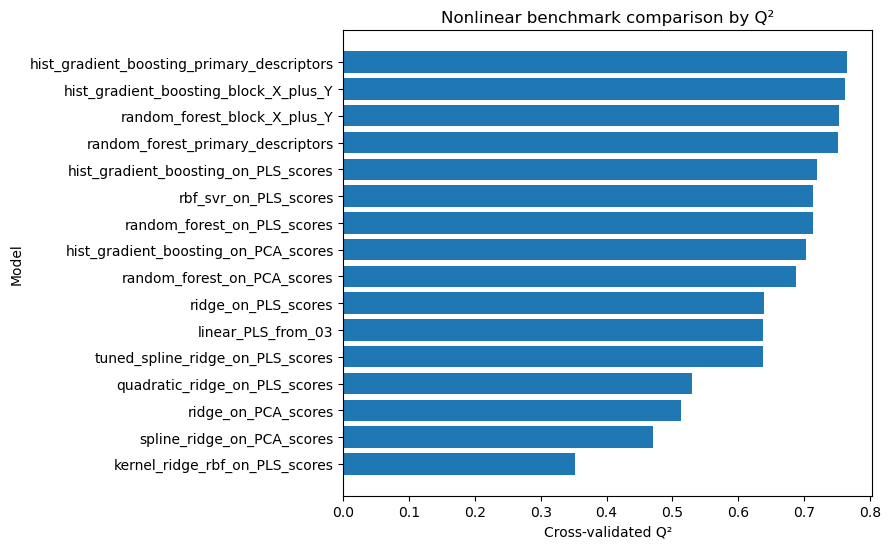

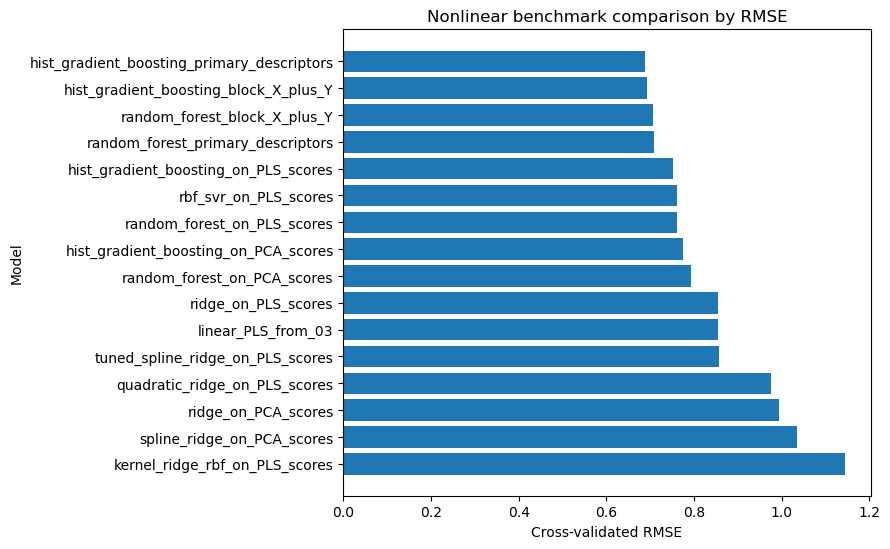

In [61]:
all_predictions = pd.concat(predictions_all, ignore_index=True)
all_fold_metrics = pd.concat(fold_metrics_all, ignore_index=True) if len(fold_metrics_all) > 0 else pd.DataFrame()

all_predictions.to_csv(RESULTS_DIR / "nonlinear_model_cv_predictions_all_models.csv", index=False)
all_fold_metrics.to_csv(RESULTS_DIR / "nonlinear_model_fold_metrics_all_models.csv", index=False)

# Q² comparison
plot_df = model_comparison.sort_values("q2_cv_global", ascending=True)
plt.figure(figsize=(9, max(5, 0.35 * len(plot_df))))
plt.barh(plot_df["model_name"], plot_df["q2_cv_global"])
plt.xlabel("Cross-validated Q²")
plt.ylabel("Model")
plt.title("Nonlinear benchmark comparison by Q²")
plt.tight_layout()
plt.savefig(NONLINEAR_FIGURES_DIR / "nonlinear_model_q2_comparison.png", dpi=200)
plt.show()

# RMSE comparison
plot_df = model_comparison.sort_values("rmse_cv_global", ascending=False)
plt.figure(figsize=(9, max(5, 0.35 * len(plot_df))))
plt.barh(plot_df["model_name"], plot_df["rmse_cv_global"])
plt.xlabel("Cross-validated RMSE")
plt.ylabel("Model")
plt.title("Nonlinear benchmark comparison by RMSE")
plt.tight_layout()
plt.savefig(NONLINEAR_FIGURES_DIR / "nonlinear_model_rmse_comparison.png", dpi=200)
plt.show()

In [62]:
def model_calibration_summary(pred_df):
    records = []

    for model_name, group in pred_df.groupby("model_name"):
        coef = np.polyfit(
            group["predicted_pIC50_cv"],
            group["observed_pIC50"],
            deg=1,
        )

        calibration_slope = coef[0]
        calibration_intercept = coef[1]

        records.append({
            "model_name": model_name,
            "calibration_intercept_observed_on_predicted": calibration_intercept,
            "calibration_slope_observed_on_predicted": calibration_slope,
            "mean_residual": group["residual_cv"].mean(),
            "median_residual": group["residual_cv"].median(),
            "rmse_cv_global": rmse(
                group["observed_pIC50"],
                group["predicted_pIC50_cv"],
            ),
            "mae_cv_global": mean_absolute_error(
                group["observed_pIC50"],
                group["predicted_pIC50_cv"],
            ),
            "q2_cv_global": q2_score(
                group["observed_pIC50"],
                group["predicted_pIC50_cv"],
            ),
        })

    return pd.DataFrame(records)

calibration_by_model = model_calibration_summary(all_predictions)

calibration_by_model.to_csv(
    RESULTS_DIR / "nonlinear_model_calibration_summary.csv",
    index=False,
)

model_comparison = model_comparison.merge(
    calibration_by_model[
        [
            "model_name",
            "calibration_intercept_observed_on_predicted",
            "calibration_slope_observed_on_predicted",
            "mean_residual",
            "median_residual",
        ]
    ],
    on="model_name",
    how="left",
)

model_comparison.to_csv(
    RESULTS_DIR / "nonlinear_model_comparison_summary.csv",
    index=False,
)

display(
    model_comparison[
        [
            "model_name",
            "model_family",
            "q2_cv_global",
            "rmse_cv_global",
            "delta_q2_vs_linear_pls",
            "delta_rmse_vs_linear_pls",
            "calibration_slope_observed_on_predicted",
            "calibration_intercept_observed_on_predicted",
        ]
    ]
)

,model_name,model_family,q2_cv_global,rmse_cv_global,delta_q2_vs_linear_pls,delta_rmse_vs_linear_pls,calibration_slope_observed_on_predicted,calibration_intercept_observed_on_predicted
0,hist_gradient_boosting_primary_descriptors,nonparametric_reference_on_raw_descriptors,0.765690,0.688648,0.127331,-0.166893,0.994822,0.020571
1,hist_gradient_boosting_block_X_plus_Y,nonparametric_reference_on_raw_descriptors,0.762736,0.692975,0.124377,-0.162566,0.991150,0.048122
2,random_forest_block_X_plus_Y,nonparametric_reference_on_raw_descriptors,0.752953,0.707118,0.114594,-0.148423,1.099395,-0.668023
3,random_forest_primary_descriptors,nonparametric_reference_on_raw_descriptors,0.752277,0.708085,0.113918,-0.147457,1.099492,-0.670866
4,hist_gradient_boosting_on_PLS_scores,nonparametric_on_PLS_scores,0.720488,0.752146,0.082130,-0.103396,0.968592,0.201676
5,rbf_svr_on_PLS_scores,nonparametric_on_PLS_scores,0.713772,0.761128,0.075413,-0.094413,0.945834,0.320113
6,random_forest_on_PLS_scores,nonparametric_on_PLS_scores,0.713609,0.761345,0.075250,-0.094196,1.141810,-0.937170
7,hist_gradient_boosting_on_PCA_scores,models_on_PCA_scores,0.702784,0.775600,0.064426,-0.079941,0.984634,0.093186
8,random_forest_on_PCA_scores,models_on_PCA_scores,0.688569,0.793931,0.050211,-0.061610,1.161836,-1.072882
9,ridge_on_PLS_scores,linear_on_PLS_scores,0.639114,0.854648,0.000755,-0.000894,0.923670,0.504684


# 9. Residual-Pattern Comparison

The main question is whether nonlinear benchmarks reduce systematic residual patterns observed in the linear PLS model, especially at low and high pIC50 values.

In [73]:
# Residual summary by observed pIC50 bins
activity_bins = (
    all_predictions[["SMILES", "observed_pIC50"]]
    .drop_duplicates()
    .copy()
)

activity_bins["pIC50_bin"] = pd.qcut(
    activity_bins["observed_pIC50"],
    q=5,
    duplicates="drop",
).astype(str)

all_predictions = all_predictions.drop(columns=["pIC50_bin"], errors="ignore").merge(
    activity_bins[["SMILES", "pIC50_bin"]],
    on="SMILES",
    how="left",
)

residual_by_bin = (
    all_predictions
    .groupby(["model_name", "feature_set_name", "pIC50_bin"])
    .agg(
        n_compounds=("SMILES", "count"),
        mean_observed_pIC50=("observed_pIC50", "mean"),
        mean_predicted_pIC50=("predicted_pIC50_cv", "mean"),
        mean_residual=("residual_cv", "mean"),
        mean_abs_residual=("abs_residual_cv", "mean"),
        median_abs_residual=("abs_residual_cv", "median"),
    )
    .reset_index()
)

residual_by_bin.to_csv(RESULTS_DIR / "nonlinear_residual_by_observed_pIC50_bin.csv", index=False)
display(residual_by_bin.head(20))

,model_name,feature_set_name,pIC50_bin,n_compounds,mean_observed_pIC50,mean_predicted_pIC50,mean_residual,mean_abs_residual,median_abs_residual
0,hist_gradient_boosting_block_X_plus_Y,block_X_plus_block_Y,"(2.455, 5.16]",395,4.675306,5.050400,-0.375094,0.494879,0.310749
1,hist_gradient_boosting_block_X_plus_Y,block_X_plus_block_Y,"(5.16, 6.126]",395,5.640437,5.930645,-0.290208,0.493476,0.375529
2,hist_gradient_boosting_block_X_plus_Y,block_X_plus_block_Y,"(6.126, 6.963]",396,6.570006,6.624482,-0.054476,0.458265,0.337868
3,hist_gradient_boosting_block_X_plus_Y,block_X_plus_block_Y,"(6.963, 7.921]",397,7.382597,7.172266,0.210331,0.473857,0.361175
4,hist_gradient_boosting_block_X_plus_Y,block_X_plus_block_Y,"(7.921, 10.337]",391,8.679420,8.217487,0.461934,0.575952,0.380583
5,hist_gradient_boosting_on_PCA_scores,PCA_scores_foldwise,"(2.455, 5.16]",395,4.675306,5.136363,-0.461057,0.600828,0.378058
6,hist_gradient_boosting_on_PCA_scores,PCA_scores_foldwise,"(5.16, 6.126]",395,5.640437,6.026221,-0.385784,0.570619,0.450356
7,hist_gradient_boosting_on_PCA_scores,PCA_scores_foldwise,"(6.126, 6.963]",396,6.570006,6.611740,-0.041734,0.520256,0.436167
8,hist_gradient_boosting_on_PCA_scores,PCA_scores_foldwise,"(6.963, 7.921]",397,7.382597,7.100421,0.282175,0.548246,0.469631
9,hist_gradient_boosting_on_PCA_scores,PCA_scores_foldwise,"(7.921, 10.337]",391,8.679420,8.109248,0.570173,0.670149,0.499575


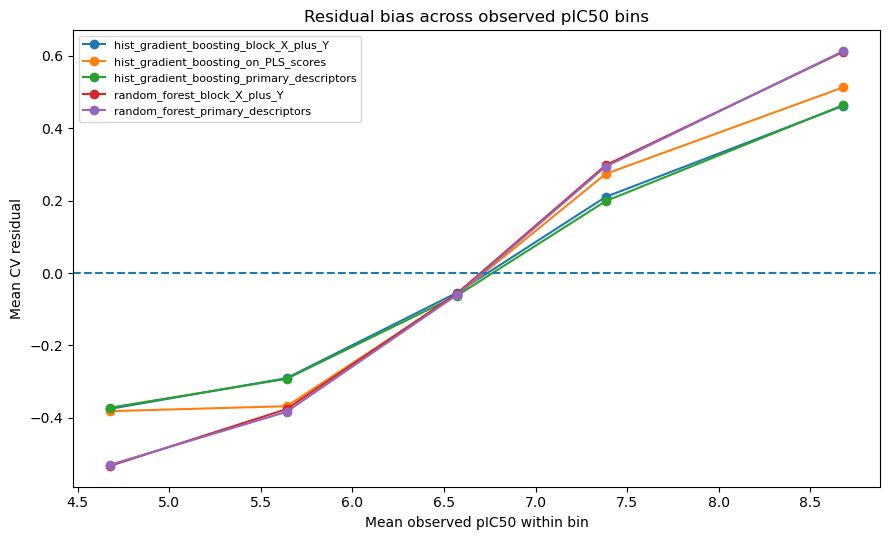

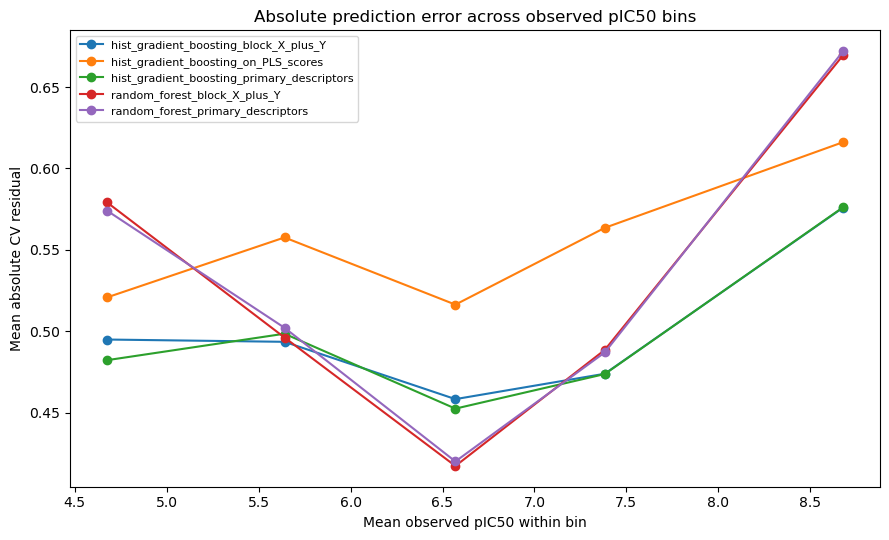

In [64]:
# Plot residual-by-bin for top models
top_models = model_comparison.head(min(5, len(model_comparison)))["model_name"].tolist()
plot_df = residual_by_bin[residual_by_bin["model_name"].isin(top_models)].copy()

plt.figure(figsize=(9, 5.5))
for model_name, group in plot_df.groupby("model_name"):
    group = group.sort_values("mean_observed_pIC50")
    plt.plot(
        group["mean_observed_pIC50"],
        group["mean_residual"],
        marker="o",
        label=model_name,
    )
plt.axhline(0, linestyle="--")
plt.xlabel("Mean observed pIC50 within bin")
plt.ylabel("Mean CV residual")
plt.title("Residual bias across observed pIC50 bins")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(NONLINEAR_FIGURES_DIR / "nonlinear_residual_bias_by_pIC50_bin.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5.5))
for model_name, group in plot_df.groupby("model_name"):
    group = group.sort_values("mean_observed_pIC50")
    plt.plot(
        group["mean_observed_pIC50"],
        group["mean_abs_residual"],
        marker="o",
        label=model_name,
    )
plt.xlabel("Mean observed pIC50 within bin")
plt.ylabel("Mean absolute CV residual")
plt.title("Absolute prediction error across observed pIC50 bins")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(NONLINEAR_FIGURES_DIR / "nonlinear_abs_residual_by_pIC50_bin.png", dpi=200)
plt.show()

In [65]:
residual_bias_records = []

for model_name, group in residual_by_bin.groupby("model_name"):
    group = group.sort_values("mean_observed_pIC50").reset_index(drop=True)

    low_bin_residual = group.loc[0, "mean_residual"]
    high_bin_residual = group.loc[len(group) - 1, "mean_residual"]

    residual_bias_records.append({
        "model_name": model_name,
        "low_activity_bin_mean_residual": low_bin_residual,
        "high_activity_bin_mean_residual": high_bin_residual,
        "high_minus_low_residual_gap": high_bin_residual - low_bin_residual,
        "max_abs_bin_mean_residual": group["mean_residual"].abs().max(),
        "mean_abs_bin_mean_residual": group["mean_residual"].abs().mean(),
        "mean_bin_abs_residual": group["mean_abs_residual"].mean(),
    })

residual_bias_summary = pd.DataFrame(residual_bias_records)

residual_bias_summary.to_csv(
    RESULTS_DIR / "nonlinear_residual_bias_compression_summary.csv",
    index=False,
)

model_comparison = model_comparison.merge(
    residual_bias_summary,
    on="model_name",
    how="left",
)

model_comparison.to_csv(
    RESULTS_DIR / "nonlinear_model_comparison_summary.csv",
    index=False,
)

display(
    model_comparison[
        [
            "model_name",
            "model_family",
            "q2_cv_global",
            "rmse_cv_global",
            "high_minus_low_residual_gap",
            "max_abs_bin_mean_residual",
            "mean_abs_bin_mean_residual",
        ]
    ].sort_values("mean_abs_bin_mean_residual")
)

,model_name,model_family,q2_cv_global,rmse_cv_global,high_minus_low_residual_gap,max_abs_bin_mean_residual,mean_abs_bin_mean_residual
0,hist_gradient_boosting_primary_descriptors,nonparametric_reference_on_raw_descriptors,0.765690,0.688648,0.835642,0.463820,0.277822
1,hist_gradient_boosting_block_X_plus_Y,nonparametric_reference_on_raw_descriptors,0.762736,0.692975,0.837028,0.461934,0.278408
5,rbf_svr_on_PLS_scores,nonparametric_on_PLS_scores,0.713772,0.761128,0.879190,0.452247,0.303710
4,hist_gradient_boosting_on_PLS_scores,nonparametric_on_PLS_scores,0.720488,0.752146,0.894260,0.512933,0.319277
15,kernel_ridge_rbf_on_PLS_scores,nonparametric_on_PLS_scores,0.351604,1.145571,0.825529,0.812225,0.320486
7,hist_gradient_boosting_on_PCA_scores,models_on_PCA_scores,0.702784,0.775600,1.031230,0.570173,0.348185
2,random_forest_block_X_plus_Y,nonparametric_reference_on_raw_descriptors,0.752953,0.707118,1.143594,0.610919,0.374724
3,random_forest_primary_descriptors,nonparametric_reference_on_raw_descriptors,0.752277,0.708085,1.142597,0.612915,0.376040
10,linear_PLS_from_03,linear_PLS_baseline,0.638359,0.855541,1.045354,0.630444,0.383979
9,ridge_on_PLS_scores,linear_on_PLS_scores,0.639114,0.854648,1.063983,0.639655,0.388818


# 10. Observed-vs-Predicted and Residual Plots for Top Models

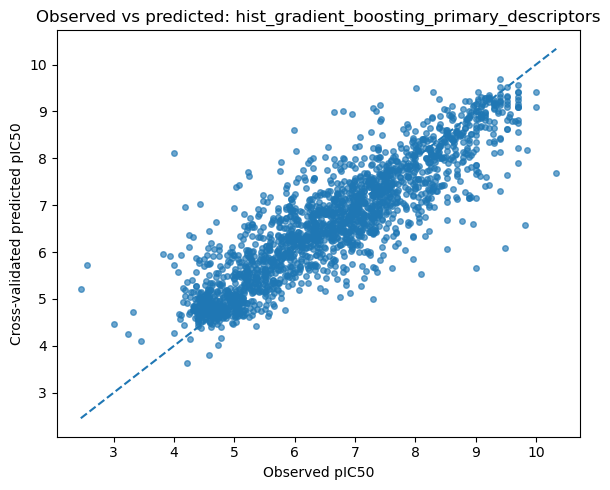

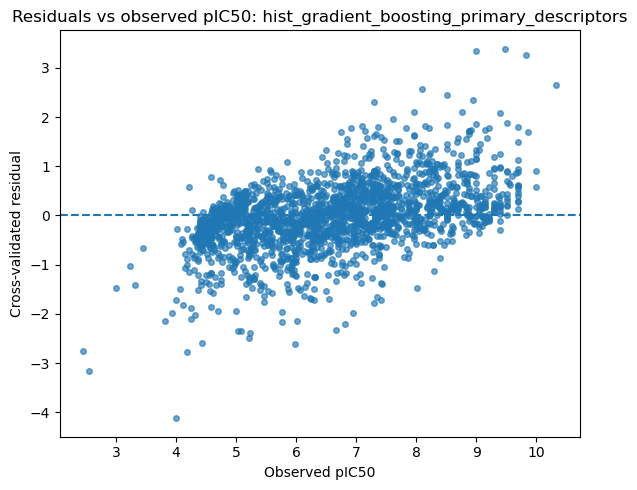

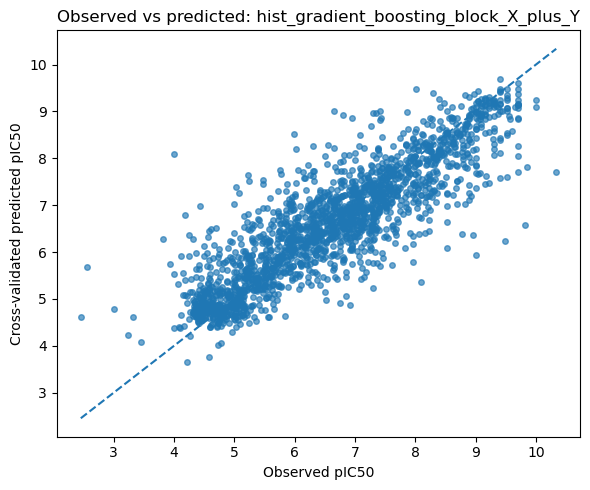

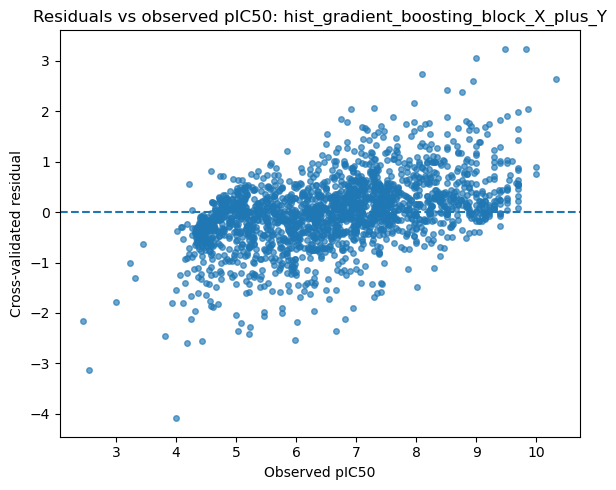

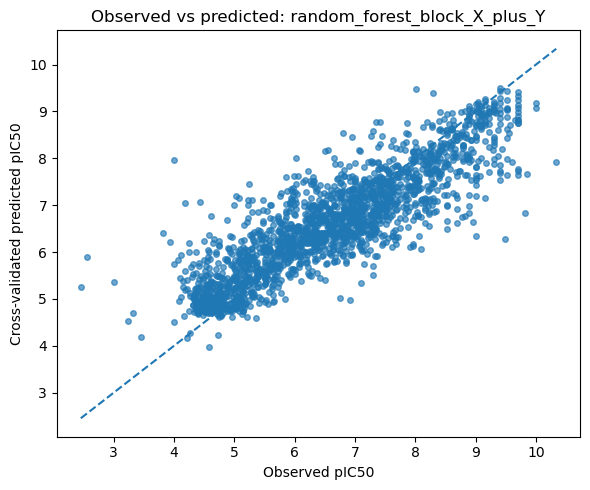

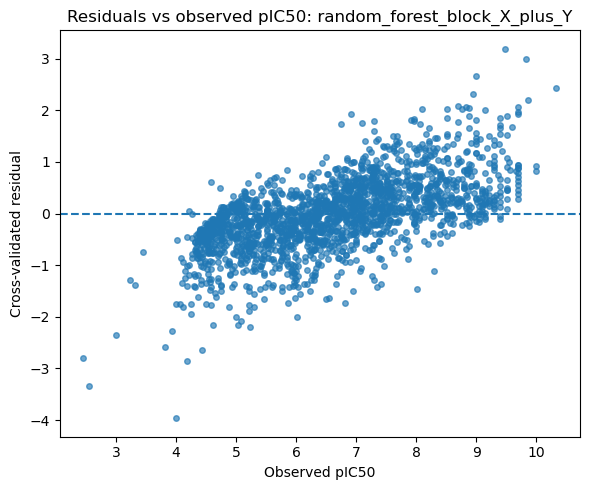

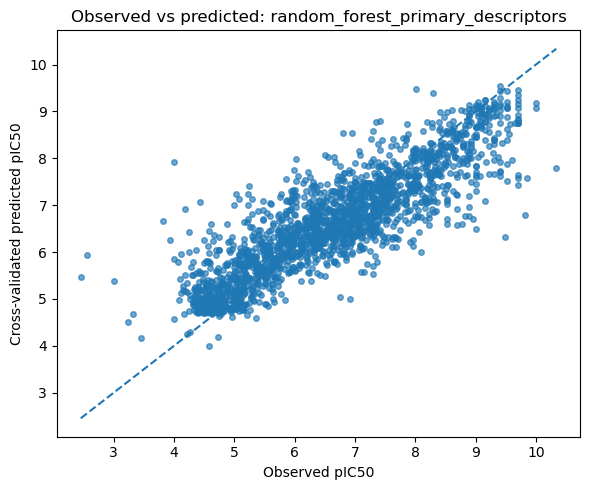

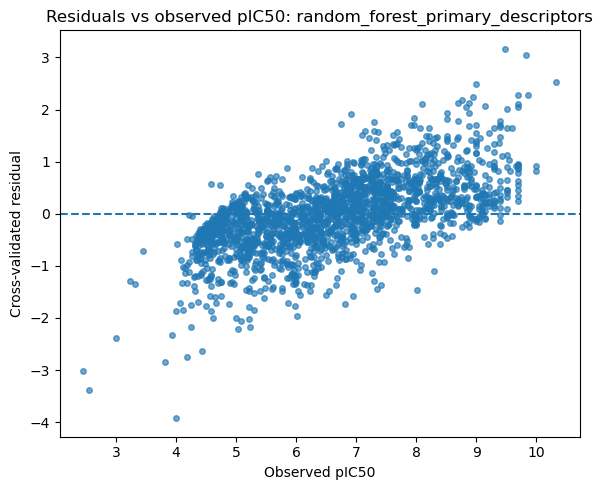

In [66]:
# Plot top 4 models by Q²
top_models_for_plots = model_comparison.head(min(4, len(model_comparison)))["model_name"].tolist()

for model_name in top_models_for_plots:
    tmp = all_predictions[all_predictions["model_name"] == model_name].copy()

    plt.figure(figsize=(6, 5))
    plt.scatter(tmp["observed_pIC50"], tmp["predicted_pIC50_cv"], s=16, alpha=0.65)
    mn = min(tmp["observed_pIC50"].min(), tmp["predicted_pIC50_cv"].min())
    mx = max(tmp["observed_pIC50"].max(), tmp["predicted_pIC50_cv"].max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observed pIC50")
    plt.ylabel("Cross-validated predicted pIC50")
    plt.title(f"Observed vs predicted: {model_name}")
    plt.tight_layout()
    plt.savefig(NONLINEAR_FIGURES_DIR / f"observed_vs_predicted_{safe_filename(model_name)}.png", dpi=200)
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(tmp["observed_pIC50"], tmp["residual_cv"], s=16, alpha=0.65)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Observed pIC50")
    plt.ylabel("Cross-validated residual")
    plt.title(f"Residuals vs observed pIC50: {model_name}")
    plt.tight_layout()
    plt.savefig(NONLINEAR_FIGURES_DIR / f"residuals_vs_observed_{safe_filename(model_name)}.png", dpi=200)
    plt.show()

# 11. Fit Best Nonlinear Benchmark on Full Data for Interpretation

This section fits the top-performing nonlinear benchmark on all training data and computes permutation importance. The interpretation is exploratory; cross-validated performance remains the source of predictive evidence.

In [67]:
def make_full_pls_score_features(X_df, y, n_components):
    """Fit scaler + PLS on the full data and return PLS score features.

    This is only used for full-data interpretation of the selected nonlinear model.
    Cross-validated performance is still computed using fold-wise PLS scores.
    """
    X_df = X_df.copy().reset_index(drop=True)
    y = pd.Series(y).astype(float).reset_index(drop=True)

    n_components = int(min(n_components, X_df.shape[1], X_df.shape[0] - 1))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)

    pls = PLSRegression(n_components=n_components)
    pls.fit(X_scaled, y)

    score_df = pd.DataFrame(
        pls.transform(X_scaled),
        columns=[f"PLS_score_{i+1}" for i in range(n_components)],
    )

    return score_df

In [68]:
def make_full_pca_score_features(X_df, n_components):
    """
    Fit scaler + PCA on the full data and return PCA score features.
    """
    X_df = X_df.copy().reset_index(drop=True)

    n_components = int(min(n_components, X_df.shape[1], X_df.shape[0] - 1))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)

    pca = PCA(n_components=n_components, svd_solver="full")
    scores = pca.fit_transform(X_scaled)

    score_df = pd.DataFrame(
        scores,
        columns=[f"PCA_score_{i+1}" for i in range(n_components)],
    )

    return score_df

In [69]:
best_row = model_comparison.iloc[0]
best_model_name = best_row["model_name"]
best_feature_set_name = best_row["feature_set_name"]

print("Best model by Q²:", best_model_name)
print("Feature set:", best_feature_set_name)

# Reconstruct the feature matrix and estimator for the best model
def get_feature_matrix_by_name(feature_set_name):
    if feature_set_name == "PLS_scores_foldwise":
        return make_full_pls_score_features(
            X_primary,
            y,
            N_LATENT_SCORES,
        )

    if feature_set_name in [
        "PLS_scores_foldwise_top8_spline",
        "PLS_scores_foldwise_top8_spline_tuned",
        "PLS_scores_foldwise_top8_quadratic",
    ]:
        return make_full_pls_score_features(
            X_primary,
            y,
            min(8, N_LATENT_SCORES),
        )

    if feature_set_name == "PCA_scores_foldwise":
        return make_full_pca_score_features(
            X_primary,
            N_LATENT_SCORES,
        )

    if feature_set_name == "PCA_scores_foldwise_top8_spline":
        return make_full_pca_score_features(
            X_primary,
            min(8, N_LATENT_SCORES),
        )

    if feature_set_name == "primary_full_constant_removed":
        return X_primary

    if feature_set_name == "block_X_plus_block_Y":
        return X_block_xy

    raise ValueError(f"Unknown feature set: {feature_set_name}")

# Dictionary for estimator reconstruction
model_registry = {}

for model_name, model, n_scores, feature_set_name in pls_score_models:
    model_registry[model_name] = model

for model_name, model, n_scores, feature_set_name in pca_score_models:
    model_registry[model_name] = model

for model_name, model, X_feat, feature_set_name in original_descriptor_models:
    model_registry[model_name] = model

if best_model_name in ["linear_PLS_from_03", "linear_PLS_reestimated"]:
    print("The best model is the linear PLS baseline; permutation importance is already covered by VIP in 03.")
    best_model = None
else:
    X_best = get_feature_matrix_by_name(best_feature_set_name)
    best_model = clone(model_registry[best_model_name])
    best_model.fit(X_best, y)
    print(best_model)

Best model by Q²: hist_gradient_boosting_primary_descriptors
Feature set: primary_full_constant_removed
HistGradientBoostingRegressor(l2_regularization=0.01, learning_rate=0.05,
                              max_iter=300, random_state=42)


,feature,importance_mean,importance_sd
367,LipoaffinityIndex,0.228078,0.003577
315,maxHsOH,0.181850,0.005597
439,MDEC-23,0.168857,0.006067
453,MLFER_A,0.082298,0.003987
249,minHsOH,0.076718,0.005345
283,minsssN,0.065360,0.002648
77,VC-5,0.065323,0.004442
38,BCUTc-1l,0.054900,0.003823
182,SHBint10,0.043400,0.003457
419,nHBAcc,0.038184,0.002238


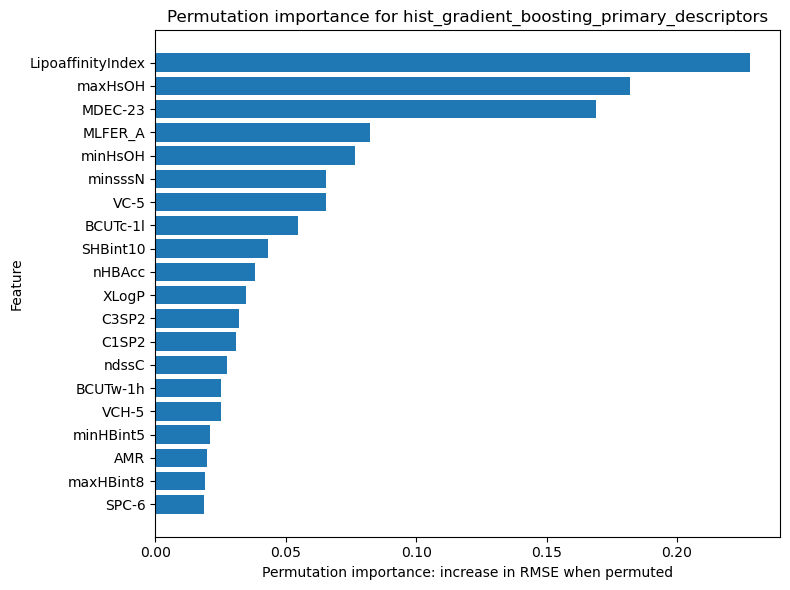

In [70]:
# Permutation importance for best nonlinear benchmark
if best_model is not None:
    perm = permutation_importance(
        best_model,
        X_best,
        y,
        n_repeats=10,
        random_state=RANDOM_STATE,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    permutation_importance_df = pd.DataFrame({
        "feature": X_best.columns,
        "importance_mean": perm.importances_mean,
        "importance_sd": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    permutation_importance_df.to_csv(
        RESULTS_DIR / "nonlinear_best_model_permutation_importance.csv",
        index=False,
    )

    display(permutation_importance_df.head(30))

    top_perm = permutation_importance_df.head(20).sort_values("importance_mean", ascending=True)
    plt.figure(figsize=(8, 6))
    plt.barh(top_perm["feature"], top_perm["importance_mean"])
    plt.xlabel("Permutation importance: increase in RMSE when permuted")
    plt.ylabel("Feature")
    plt.title(f"Permutation importance for {best_model_name}")
    plt.tight_layout()
    plt.savefig(NONLINEAR_FIGURES_DIR / "best_nonlinear_model_permutation_importance.png", dpi=200)
    plt.show()
else:
    permutation_importance_df = pd.DataFrame()

# 12. Optional Partial Dependence / ICE Plots

Partial-dependence plots are only shown for the best nonlinear model if it is not the linear PLS baseline and if the feature space is small enough to interpret.

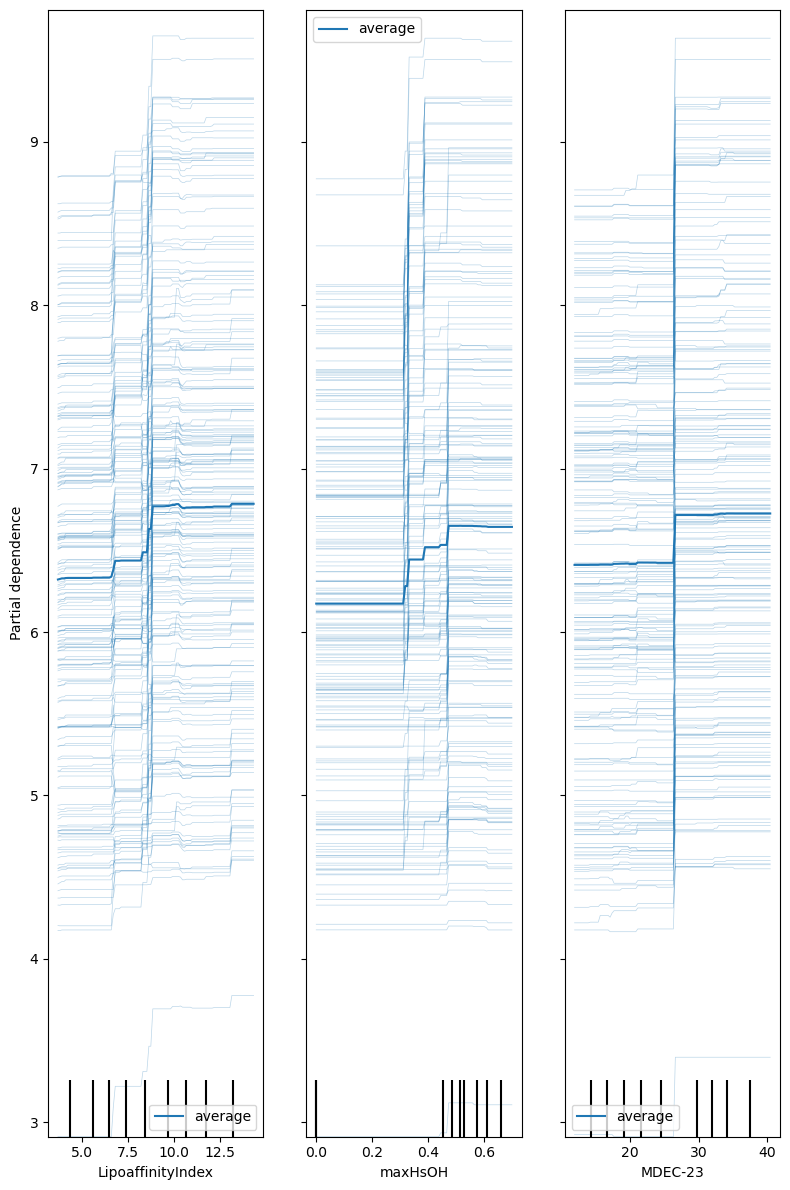

In [71]:
if best_model is not None:
    top_features = permutation_importance_df.head(min(3, len(permutation_importance_df)))["feature"].tolist()
    if len(top_features) > 0:
        fig, ax = plt.subplots(figsize=(8, 4 * len(top_features)))
        PartialDependenceDisplay.from_estimator(
            best_model,
            X_best,
            features=top_features,
            kind="both",
            subsample=200,
            random_state=RANDOM_STATE,
            ax=ax,
        )
        plt.tight_layout()
        plt.savefig(NONLINEAR_FIGURES_DIR / "best_nonlinear_model_partial_dependence_ice.png", dpi=200)
        plt.show()
else:
    print("Skipping partial dependence/ICE plots: best model is linear baseline.")

# 13. Summary for Report

In [72]:
summary_for_report = pd.DataFrame([{
    "best_model_by_q2": best_model_name,
    "best_feature_set": best_feature_set_name,
    "best_q2_cv_global": float(best_row["q2_cv_global"]),
    "best_rmse_cv_global": float(best_row["rmse_cv_global"]),
    "linear_pls_baseline_q2": float(
        model_comparison.loc[
            model_comparison["model_name"].isin(["linear_PLS_from_03", "linear_PLS_reestimated"]),
            "q2_cv_global",
        ].iloc[0]
    ) if model_comparison["model_name"].isin(["linear_PLS_from_03", "linear_PLS_reestimated"]).any() else np.nan,
    "linear_pls_baseline_rmse": float(
        model_comparison.loc[
            model_comparison["model_name"].isin(["linear_PLS_from_03", "linear_PLS_reestimated"]),
            "rmse_cv_global",
        ].iloc[0]
    ) if model_comparison["model_name"].isin(["linear_PLS_from_03", "linear_PLS_reestimated"]).any() else np.nan,
    "n_models_compared": int(len(model_comparison)),
}])

summary_for_report["delta_q2_vs_linear_pls"] = (
    summary_for_report["best_q2_cv_global"] - summary_for_report["linear_pls_baseline_q2"]
)
summary_for_report["delta_rmse_vs_linear_pls"] = (
    summary_for_report["best_rmse_cv_global"] - summary_for_report["linear_pls_baseline_rmse"]
)

summary_for_report.to_csv(RESULTS_DIR / "nonlinear_benchmark_summary_for_report.csv", index=False)
display(summary_for_report)

,best_model_by_q2,best_feature_set,best_q2_cv_global,best_rmse_cv_global,linear_pls_baseline_q2,linear_pls_baseline_rmse,n_models_compared,delta_q2_vs_linear_pls,delta_rmse_vs_linear_pls
0,hist_gradient_boosting_primary_descriptors,primary_full_constant_removed,0.76569,0.688648,0.638359,0.855541,16,0.127331,-0.166893


# 14. Interpretation Notes

This notebook extends the diagnostics in notebook 04 by asking whether the residual compression observed for the selected linear PLS model can be reduced by constrained nonlinear calibration models and nonparametric reference models.

The linear PLS model remains a useful chemometric baseline because it provides a transparent low-dimensional representation of the descriptor-activity relationship. Its cross-validated calibration is globally reasonable, but the residual summaries in notebook 04 show activity-range-dependent compression: low-activity compounds tend to be overpredicted, whereas high-activity compounds tend to be underpredicted.

Among models fitted on fold-wise PLS scores, nonlinear estimators such as HistGradientBoosting and RBF-SVR improved over the linear PLS baseline. This suggests that some nonlinear activity signal is present even within the supervised latent score representation. Among models fitted on fold-wise PLS scores, nonparametric estimators such as HistGradientBoosting, RBF-SVR, and Random Forest improved over the linear PLS baseline. In contrast, the more constrained smooth calibration models, including tuned spline-ridge and quadratic ridge, did not improve predictive performance. This suggests that some nonlinear activity signal exists in the PLS latent representation, but it may not be well captured by simple smooth low-dimensional basis expansions.

Tree-based models on the original descriptor representation achieved the strongest cross-validated performance. These models are treated as nonparametric reference models rather than the primary modelling framework. Their performance suggests that local descriptor interactions or nonlinear effects may be partly lost during low-dimensional PLS compression.

The Block X + Block Y descriptor set performed almost as well as the full primary descriptor set under HistGradientBoosting, supporting the relevance of the chemically motivated descriptor blocks used in the O2PLS-inspired analysis. Overall, the results motivate nonlinear extensions of latent-variable chemometric models rather than a replacement of interpretable statistical modelling by black-box prediction.